# Исследование рынка стартапов: куда инвестировать в 2015 году

**Автор:** Богдан Петрунин

**Задача.** Венчурный фонд выбирает направления и инструменты для инвестиций. Нужно подготовить данные о финансировании стартапов, изучить динамику и структуру рынка и дать рекомендации: в какие сегменты и через какие типы финансирования имело смысл вкладываться, если бы на дворе был 2015 год.

**План**
1. Загрузка данных и предобработка.
2. Инжиниринг признаков: группы компаний по срокам финансирования, деление сегментов рынка на массовые, средние и нишевые.
3. Выбросы и границы периода: типичный размер финансирования, аномалии по сегментам, полнота данных по годам.
4. Типы финансирования: объём, популярность, возвраты.
5. Динамика: размер и количество раундов по годам, растущие сегменты, доля возвращённых средств.
6. Выводы и рекомендации.

## 1. Данные и предобработка

**`cb_investments.csv`** (в архиве `cb_investments.zip`) — компании и их финансирование:
- `name`, `homepage_url` — название и сайт компании;
- `category_list` — категории через `|`, `market` — основной сегмент рынка;
- `funding_total_usd` — общий объём привлечённых инвестиций, USD;
- `status` — статус компании (`operating`, `closed` и т. д.);
- `country_code`, `state_code`, `region`, `city` — география;
- `funding_rounds` — число раундов, `participants` — число участников раундов;
- `founded_at`, `founded_month`, `founded_quarter`, `founded_year` — дата основания;
- `first_funding_at`, `mid_funding_at`, `last_funding_at` — даты первого, «среднего» и последнего раунда;
- `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market`, `product_crowdfunding` — суммы по типам финансирования;
- `round_A` … `round_H` — суммы по раундам.

**`cb_returns.csv`** — суммы, возвращённые инвесторам, по годам (`year`) и тем же типам финансирования, **в млн USD**.

Оба файла лежат в папке `data/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter


def format_money(x):
    """Сумма в USD в читаемом виде: 1.25 млрд / 3.40 млн / 350,000."""
    if pd.isna(x):
        return 'N/A'
    if abs(x) >= 1e9:
        return f'{x / 1e9:.2f} млрд'
    if abs(x) >= 1e6:
        return f'{x / 1e6:.2f} млн'
    return f'{x:,.0f}'


# подписи оси в USD: 1.5B / 20.0M
money_axis = FuncFormatter(lambda x, pos: f'{x / 1e9:.1f}B' if x >= 1e9
                           else f'{x / 1e6:.1f}M' if x >= 1e6 else f'{x:.0f}')

### 1.1. Загрузка и первичный осмотр

In [2]:
df = pd.read_csv('data/cb_investments.zip', sep=';', low_memory=False)
cb = pd.read_csv('data/cb_returns.csv')
initial_rows = len(df)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  str    
 1   homepage_url          45989 non-null  str    
 2   category_list         45477 non-null  str    
 3    market               45477 non-null  str    
 4    funding_total_usd    49438 non-null  str    
 5   status                48124 non-null  str    
 6   country_code          44165 non-null  str    
 7   state_code            30161 non-null  str    
 8   region                44165 non-null  str    
 9   city                  43322 non-null  str    
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  str    
 13  founded_month         38482 non-null  str    
 14  founded_quarter       38482 non-null  str    
 15  founded_year          38554 no

In [4]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


`cb_investments`: 54 294 строки, 40 столбцов.

- В названиях `market` и `funding_total_usd` есть пробелы по краям — их нужно убрать.
- `funding_total_usd` хранится строкой с разделителями разрядов (`9,00,00,000`) и прочерками вместо пропусков — нужно перевести в число.
- Даты хранятся строками — переведу в `datetime`.
- Около 4 860 строк не содержат никаких данных о финансировании: пропуски в `name`, `funding_rounds` и всех суммах совпадают.

In [5]:
cb.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [6]:
cb.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


`cb_returns`: 15 строк (2000–2014 годы), 14 столбцов, пропусков нет, типы корректные. Нули в `grant`, `equity_crowdfunding` и других столбцах — реальное отсутствие возвратов, а не пропуски. Суммы указаны в миллионах долларов — при сравнении с инвестициями их нужно перевести в доллары.

### 1.2. Предобработка

In [7]:
df.columns.tolist()

['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

Убираю пробелы в названиях столбцов. Такие же пробелы оказались и в самих значениях `market` — проверяю, как это влияет на число сегментов.

In [8]:
df.columns = df.columns.str.strip()

# значения market тоже записаны с пробелами по краям,
# из-за этого один сегмент дробится на несколько
print('Уникальных сегментов до очистки:', df['market'].nunique())
df['market'] = df['market'].str.strip()
print('Уникальных сегментов после очистки:', df['market'].nunique())

Уникальных сегментов до очистки: 939
Уникальных сегментов после очистки: 439


Из-за пробелов один и тот же сегмент записывался по-разному (`Software` и ` Software `), и число сегментов было завышено больше чем вдвое: 939 вместо 439. Без этой очистки деление на массовые и нишевые сегменты и поиск выбросов по сегментам дали бы неверный результат.

Теперь привожу `funding_total_usd` к числу: убираю разделители разрядов и прочерки, некорректные значения превращаются в пропуски.

In [9]:
df['funding_total_usd'] = pd.to_numeric(
    df['funding_total_usd'].str.replace(',', '', regex=False)
                           .str.replace('-', '', regex=False)
                           .str.strip(),
    errors='coerce'
)
df['funding_total_usd'].describe()

count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Столбец стал числовым: сумма финансирования известна для 40 907 компаний. Перевожу даты в `datetime` и делаю год индексом в таблице возвратов.

In [10]:
date_columns = ['founded_at', 'founded_month', 'first_funding_at',
                'mid_funding_at', 'last_funding_at']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

cb = cb.set_index('year')
df[date_columns].dtypes

founded_at          datetime64[us]
founded_month       datetime64[us]
first_funding_at    datetime64[us]
mid_funding_at      datetime64[us]
last_funding_at     datetime64[us]
dtype: object

Смотрю на пропуски:

In [11]:
missing = pd.DataFrame({
    'пропусков': df.isna().sum(),
    'доля, %': (df.isna().mean() * 100).round(2)
})
missing[missing['пропусков'] > 0].sort_values('пропусков', ascending=False)

,пропусков,"доля, %"
state_code,24133,44.45
mid_funding_at,24006,44.21
participants,23821,43.87
founded_quarter,15812,29.12
founded_month,15812,29.12
founded_year,15740,28.99
founded_at,15740,28.99
funding_total_usd,13387,24.66
city,10972,20.21
country_code,10129,18.66


- Строки без `funding_total_usd` для исследования бесполезны — удаляю их. Вместе с ними уходят и ~4 860 полностью пустых строк.
- Пропуски в текстовых столбцах (`market`, `city`, `status` и др.) заполняю заглушкой `unknown`, чтобы не терять компании.
- Пропуски в `mid_funding_at` (44%) восстанавливаю как середину между первым и последним раундом — даты первого и последнего раунда есть у всех компаний с финансированием.
- Пропуски в дате основания и `participants` оставляю: в анализе эти поля не используются.

In [12]:
# текстовые пропуски заменяю заглушкой
text_cols = df.select_dtypes(include=['object', 'string']).columns
df[text_cols] = df[text_cols].fillna('unknown')

# полные дубликаты (в том числе пустые строки без данных)
df = df.drop_duplicates()

# строки без суммы финансирования для анализа бесполезны
df = df.dropna(subset=['funding_total_usd'])

# пропуски в mid_funding_at — середина между первым и последним раундом
mask = df['mid_funding_at'].isna()
df.loc[mask, 'mid_funding_at'] = (
    df.loc[mask, 'first_funding_at']
    + (df.loc[mask, 'last_funding_at'] - df.loc[mask, 'first_funding_at']) / 2
)

remaining = df.isna().sum()
remaining[remaining > 0]

participants     13576
founded_at        8706
founded_month     8772
founded_year      8706
dtype: int64

Остались пропуски только в полях, которые для анализа не нужны.

In [13]:
final_rows = len(df)
removed = initial_rows - final_rows
print(f'Было строк: {initial_rows:,}')
print(f'Осталось строк: {final_rows:,} ({final_rows / initial_rows:.1%})')
print(f'Удалено: {removed:,} ({removed / initial_rows:.1%})')

Было строк: 54,294
Осталось строк: 40,907 (75.3%)
Удалено: 13,387 (24.7%)


**Итог предобработки.** Удалено 24,7% строк — это компании без данных о финансировании. Осталось 40 907 компаний, этого достаточно для исследования.

---

## 2. Инжиниринг признаков

### 2.1. Группы компаний по срокам финансирования

Делю компании на три группы:
- **единичное финансирование** — был один раунд;
- **срок финансирования до года** — между первым и последним раундом прошло не больше 365 дней;
- **срок финансирования более года**.

Сравниваю группы по числу компаний и по объёму привлечённых денег.

In [14]:
days = (df['last_funding_at'] - df['first_funding_at']).dt.days

df['group'] = np.select(
    [(df['funding_rounds'] == 1) | days.isna(), days <= 365],
    ['Единичное финансирование', 'Срок финансирования до года'],
    default='Срок финансирования более года'
)

group_stats = df.groupby('group').agg(
    companies=('name', 'count'),
    funding=('funding_total_usd', 'sum')
)
group_stats['companies_%'] = (group_stats['companies'] / group_stats['companies'].sum() * 100).round(1)
group_stats['funding_%'] = (group_stats['funding'] / group_stats['funding'].sum() * 100).round(1)
group_stats

,companies,funding,companies_%,funding_%
group,,,,
Единичное финансирование,24113,1.993044e+11,58.9,30.6
Срок финансирования более года,12293,4.027433e+11,30.1,61.9
Срок финансирования до года,4501,4.888598e+10,11.0,7.5


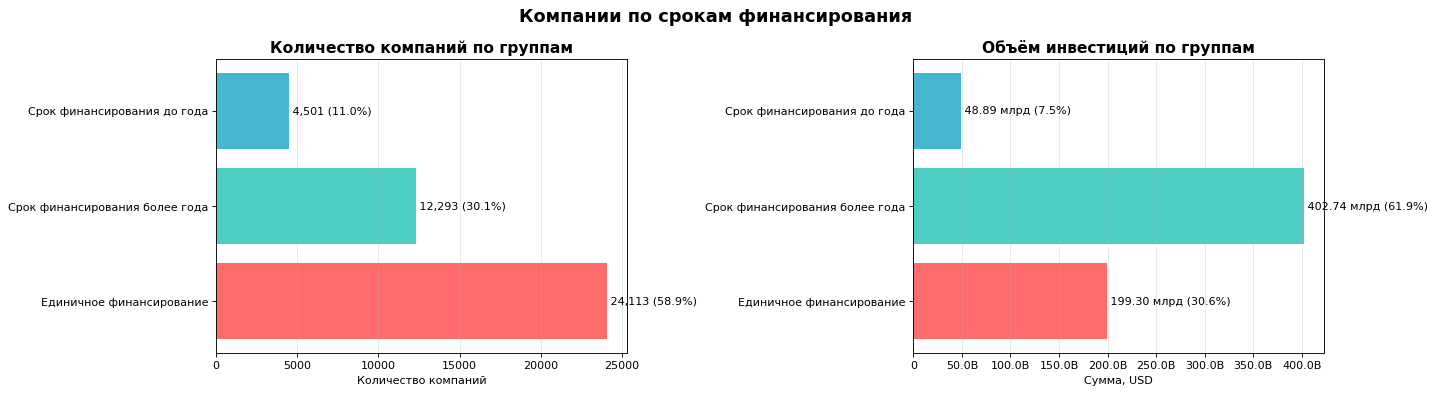

In [15]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.barh(group_stats.index, group_stats['companies'], color=colors)
ax1.set_title('Количество компаний по группам', fontsize=14, weight='bold')
ax1.set_xlabel('Количество компаний')
ax1.grid(axis='x', alpha=0.3)
for i, (v, p) in enumerate(zip(group_stats['companies'], group_stats['companies_%'])):
    ax1.text(v, i, f' {v:,} ({p}%)', va='center')

ax2.barh(group_stats.index, group_stats['funding'], color=colors)
ax2.set_title('Объём инвестиций по группам', fontsize=14, weight='bold')
ax2.set_xlabel('Сумма, USD')
ax2.xaxis.set_major_formatter(money_axis)
ax2.grid(axis='x', alpha=0.3)
for i, (v, p) in enumerate(zip(group_stats['funding'], group_stats['funding_%'])):
    ax2.text(v, i, f' {format_money(v)} ({p}%)', va='center')

plt.suptitle('Компании по срокам финансирования', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

- **59% компаний** (24 113) привлекли деньги только один раз, но получили лишь **31%** всех инвестиций.
- Компании, которые финансировались **дольше года**, — это 30% выборки (12 293), но на них приходится **62%** всех денег.
- Группа «до года» — 11% компаний и 7,5% инвестиций.

Деньги концентрируются в компаниях, которые смогли привлекать финансирование несколько лет подряд: подтверждённая способность проходить следующие раунды — сильный сигнал для инвесторов.

### 2.2. Массовые, средние и нишевые сегменты

Считаю, сколько компаний в каждом сегменте `market`:
- **массовый** — больше 120 компаний;
- **средний** — от 35 до 120;
- **нишевый** — меньше 35.

In [16]:
MASS_MIN, MID_MIN = 121, 35   # >120 — массовый, 35–120 — средний, <35 — нишевый

market_counts = df['market'].value_counts()

def segment_category(n):
    if n >= MASS_MIN:
        return 'Массовый'
    if n >= MID_MIN:
        return 'Средний'
    return 'Нишевый'

segments = pd.DataFrame({'companies': market_counts,
                         'category': market_counts.map(segment_category)})

segment_summary = segments.groupby('category').agg(
    segments=('companies', 'size'),
    companies=('companies', 'sum')
).reindex(['Массовый', 'Средний', 'Нишевый'])
segment_summary['segments_%'] = (segment_summary['segments'] / segment_summary['segments'].sum() * 100).round(1)
segment_summary['companies_%'] = (segment_summary['companies'] / segment_summary['companies'].sum() * 100).round(1)
segment_summary

,segments,companies,segments_%,companies_%
category,,,,
Массовый,49,36236,12.4,88.6
Средний,57,3841,14.4,9.4
Нишевый,289,830,73.2,2.0


In [17]:
market_counts.head(15)

market
Software               4812
Biotechnology          3590
unknown                2503
Mobile                 2344
E-Commerce             1866
Curated Web            1693
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Games                  1117
Advertising            1107
Hardware + Software    1062
Social Media           1003
Health and Wellness     873
Education               844
Name: count, dtype: int64

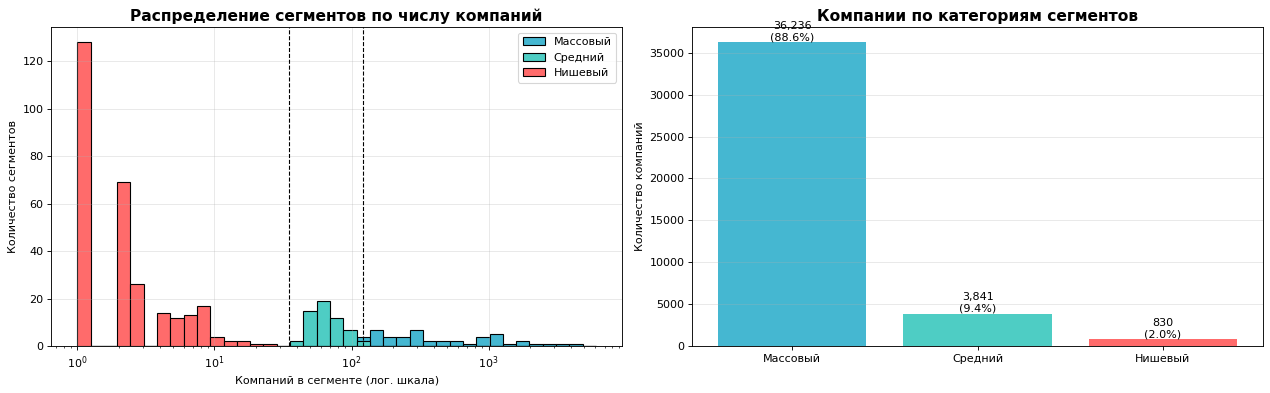

In [18]:
cat_colors = {'Массовый': '#45B7D1', 'Средний': '#4ECDC4', 'Нишевый': '#FF6B6B'}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# распределение размеров сегментов (логарифмическая шкала — размеры отличаются на порядки)
bins = np.logspace(0, np.log10(market_counts.max()) + 0.1, 40)
for cat, color in cat_colors.items():
    ax1.hist(segments.loc[segments['category'] == cat, 'companies'],
             bins=bins, color=color, edgecolor='black', label=cat)
ax1.axvline(MID_MIN, color='black', linestyle='--', linewidth=1)
ax1.axvline(MASS_MIN, color='black', linestyle='--', linewidth=1)
ax1.set_xscale('log')
ax1.set_title('Распределение сегментов по числу компаний', fontsize=14, weight='bold')
ax1.set_xlabel('Компаний в сегменте (лог. шкала)')
ax1.set_ylabel('Количество сегментов')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.bar(segment_summary.index, segment_summary['companies'],
        color=[cat_colors[c] for c in segment_summary.index])
ax2.set_title('Компании по категориям сегментов', fontsize=14, weight='bold')
ax2.set_ylabel('Количество компаний')
ax2.grid(axis='y', alpha=0.3)
for i, (v, p) in enumerate(zip(segment_summary['companies'], segment_summary['companies_%'])):
    ax2.text(i, v, f'{v:,}\n({p}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

- **Нишевых сегментов большинство** — 289 из 395 (73%), но в них всего 830 компаний (2%).
- **Массовых сегментов 49** (12%), зато в них **89% всех компаний**. Крупнейшие — Software, Biotechnology, Mobile, E-Commerce.
- Средних сегментов 57 (14%), в них 9% компаний.

Рынок сильно сконцентрирован. Для анализа динамики оставляю названия массовых сегментов, а средние и нишевые объединяю в `mid` и `niche` — по отдельности они слишком малы для устойчивых выводов.

In [19]:
# массовые сегменты оставляю, средние и нишевые объединяю в mid и niche
replace_map = segments['category'].map({'Средний': 'mid', 'Нишевый': 'niche'}).dropna()
df['market'] = df['market'].replace(replace_map.to_dict())
df['market'].value_counts().head(10)

market
Software               4812
mid                    3841
Biotechnology          3590
unknown                2503
Mobile                 2344
E-Commerce             1866
Curated Web            1693
Enterprise Software    1381
Health Care            1185
Clean Technology       1180
Name: count, dtype: int64

## 3. Выбросы и границы периода

### 3.1. Типичный размер финансирования

Заказчику важен обычный объём финансирования одной компании. Смотрю на распределение `funding_total_usd` на логарифмической шкале — суммы различаются на порядки.

Среднее: 15.91 млн
Медиана: 2.00 млн
Типичный интервал (Q1–Q3): 350,000 – 10.00 млн
Минимум: 1, максимум: 30.08 млрд


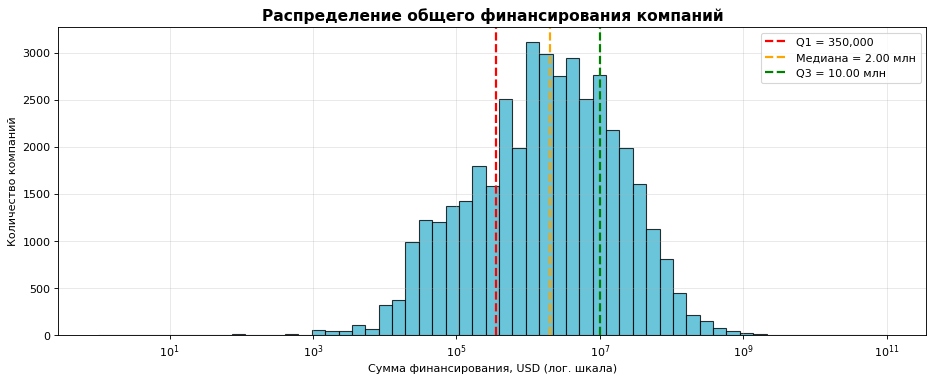

In [20]:
q = df['funding_total_usd'].quantile([0.25, 0.5, 0.75])
print(f"Среднее: {format_money(df['funding_total_usd'].mean())}")
print(f"Медиана: {format_money(q[0.5])}")
print(f"Типичный интервал (Q1–Q3): {format_money(q[0.25])} – {format_money(q[0.75])}")
print(f"Минимум: {format_money(df['funding_total_usd'].min())}, "
      f"максимум: {format_money(df['funding_total_usd'].max())}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(df['funding_total_usd'], bins=np.logspace(0, 11, 60),
        color='#45B7D1', edgecolor='black', alpha=0.8)
ax.set_xscale('log')
for value, color, label in [(q[0.25], 'red', 'Q1'), (q[0.5], 'orange', 'Медиана'), (q[0.75], 'green', 'Q3')]:
    ax.axvline(value, color=color, linestyle='--', linewidth=2, label=f'{label} = {format_money(value)}')
ax.set_title('Распределение общего финансирования компаний', fontsize=14, weight='bold')
ax.set_xlabel('Сумма финансирования, USD (лог. шкала)')
ax.set_ylabel('Количество компаний')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Распределение сильно скошено вправо: среднее (15,9 млн) почти в 8 раз больше медианы (2 млн) — его тянут вверх единичные мегасделки до 30 млрд.

**Типичное финансирование компании — от 350 тыс. до 10 млн USD** (межквартильный интервал, в нём половина компаний).

Размеры компаний в разных сегментах сильно отличаются, поэтому аномально большие суммы ищу **внутри каждого сегмента** по правилу 1,5 IQR.

Всего компаний с аномальным финансированием: 5,244 (12.8%)


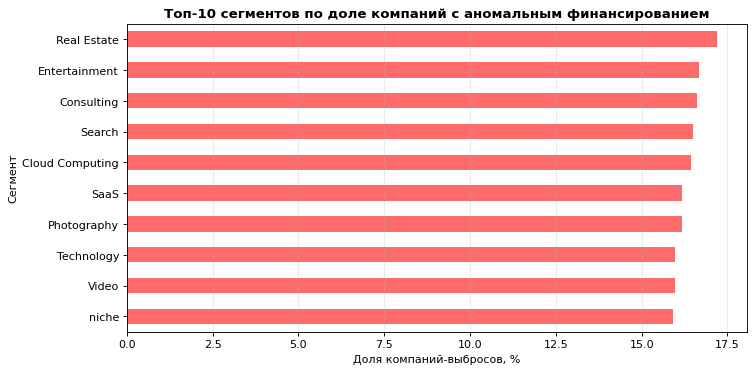

market
Real Estate        17.2
Entertainment      16.7
Consulting         16.6
Search             16.5
Cloud Computing    16.4
Photography        16.2
SaaS               16.2
Technology         16.0
Video              16.0
niche              15.9
Name: outlier, dtype: float64

In [21]:
def upper_outliers(s):
    """Флаг аномально высоких значений по правилу 1.5 IQR."""
    q1, q3 = s.quantile([0.25, 0.75])
    return s > q3 + 1.5 * (q3 - q1)

df['outlier'] = df.groupby('market')['funding_total_usd'].transform(upper_outliers).astype(bool)

outlier_share = (df.groupby('market')['outlier'].mean() * 100).sort_values(ascending=False)
print(f"Всего компаний с аномальным финансированием: {df['outlier'].sum():,} ({df['outlier'].mean():.1%})")

top = outlier_share.head(10).sort_values()
top.plot(kind='barh', figsize=(10, 5), color='#FF6B6B')
plt.title('Топ-10 сегментов по доле компаний с аномальным финансированием', weight='bold')
plt.xlabel('Доля компаний-выбросов, %')
plt.ylabel('Сегмент')
plt.grid(axis='x', alpha=0.3)
plt.show()

outlier_share.head(10).round(1)

Аномально большое финансирование получили 5 244 компании (12,8%). Больше всего таких компаний в Real Estate (17%), Entertainment, Consulting, Search и Cloud Computing (около 16,5%): примерно каждая шестая компания в этих сегментах привлекла сумму, нетипичную для своего рынка.

Такие компании сильно искажают суммарные показатели сегмента, поэтому для анализа динамики и типичных значений их исключаю.

### 3.2. Границы периода

Проверяю, полные ли данные за 2014 год, исключаю выбросы и оставляю только годы, в которых было не меньше 50 раундов финансирования: в более «редкие» годы данных слишком мало для выводов. Год раунда определяю по `mid_funding_at`.

In [22]:
df['funding_year'] = df['mid_funding_at'].dt.year

# полнота 2014 года: есть ли раунды во всех месяцах
last_year = df.loc[df['funding_year'] == 2014, 'mid_funding_at'].dt.month.value_counts().sort_index()
print('Компаний по месяцам 2014 года:')
print(last_year.to_string())
print('Последняя дата раунда в данных:', df['last_funding_at'].max().date())

Компаний по месяцам 2014 года:
mid_funding_at
1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
Последняя дата раунда в данных: 2014-12-31


Раунды есть во всех месяцах 2014 года, последняя дата финансирования — 31 декабря 2014, поэтому считаю год полным. При этом в ноябре и особенно в декабре раундов заметно меньше, чем в остальные месяцы: похоже, конец года представлен в данных не полностью. Это нужно помнить, когда сравниваю 2014 год с 2013-м.

In [23]:
before = len(df)
df = df[~df['outlier']]
print(f'Исключено компаний-выбросов: {before - len(df):,} ({(before - len(df)) / before:.1%})')

rounds_by_year = df.groupby('funding_year')['funding_rounds'].sum()
years_ok = rounds_by_year[rounds_by_year >= 50].index

before = len(df)
df = df[df['funding_year'].isin(years_ok)].copy()
df['funding_year'] = df['funding_year'].astype(int)
print(f'Годы с 50+ раундами: {int(years_ok.min())}–{int(years_ok.max())}')
print(f'Исключено компаний из «редких» лет: {before - len(df):,}')
print(f'Итоговая выборка: {len(df):,} компаний')

Исключено компаний-выбросов: 5,244 (12.8%)
Годы с 50+ раундами: 2000–2014
Исключено компаний из «редких» лет: 75
Итоговая выборка: 35,588 компаний


После исключения выбросов (12,8%) и «редких» лет осталось **35 588 компаний за 2000–2014 годы**. Дальнейший анализ веду на этой выборке.

---

## 4. Типы финансирования

Сравниваю типы финансирования по суммарному объёму и популярности — сколько компаний получили хоть какую-то сумму этого типа.

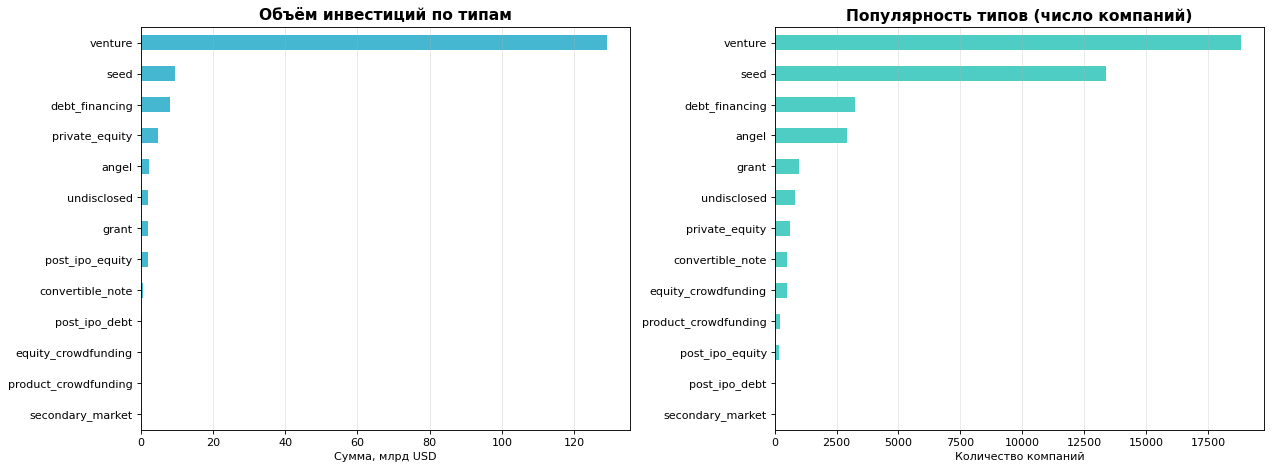

,"сумма, млрд USD",компаний,"средняя сумма на компанию, млн USD"
venture,129.09,18820,6.86
seed,9.43,13375,0.71
debt_financing,8.18,3265,2.50
private_equity,4.84,634,7.64
angel,2.48,2937,0.84
undisclosed,2.10,813,2.58
grant,1.98,1003,1.97
post_ipo_equity,1.95,164,11.87
convertible_note,0.57,521,1.09
post_ipo_debt,0.29,27,10.62


In [24]:
funding_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed',
                 'convertible_note', 'debt_financing', 'angel', 'grant',
                 'private_equity', 'post_ipo_equity', 'post_ipo_debt',
                 'secondary_market', 'product_crowdfunding']

types = pd.DataFrame({
    'сумма, млрд USD': df[funding_types].sum() / 1e9,
    'компаний': (df[funding_types] > 0).sum(),
})
types['средняя сумма на компанию, млн USD'] = types['сумма, млрд USD'] * 1e3 / types['компаний']
types = types.sort_values('сумма, млрд USD', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
types['сумма, млрд USD'].sort_values().plot(kind='barh', ax=ax1, color='#45B7D1')
ax1.set_title('Объём инвестиций по типам', fontsize=14, weight='bold')
ax1.set_xlabel('Сумма, млрд USD')
ax1.grid(axis='x', alpha=0.3)

types['компаний'].sort_values().plot(kind='barh', ax=ax2, color='#4ECDC4')
ax2.set_title('Популярность типов (число компаний)', fontsize=14, weight='bold')
ax2.set_xlabel('Количество компаний')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

types.round(2)

- **Venture** — абсолютный лидер: 129 млрд USD (≈ 80% всех денег) и 18 820 компаний.
- **Seed** — второй по популярности (13 375 компаний), но чеки небольшие: в среднем ~0,7 млн на компанию. Это массовый инструмент ранней стадии.
- **Angel** похож на seed: почти 3 000 компаний, ~0,8 млн на компанию.
- **Редкие, но крупные** — `post_ipo_equity` (164 компании, ~11,9 млн на компанию), `post_ipo_debt` (27 компаний, ~10,6 млн), `private_equity` (634 компании, ~7,6 млн). Это инструменты для зрелых компаний.
- Краудфандинг, конвертируемые займы и вторичный рынок — мелкие и по объёму, и по числу сделок.

Теперь смотрю, сколько денег вернулось инвесторам по каждому типу за 2000–2014 годы.

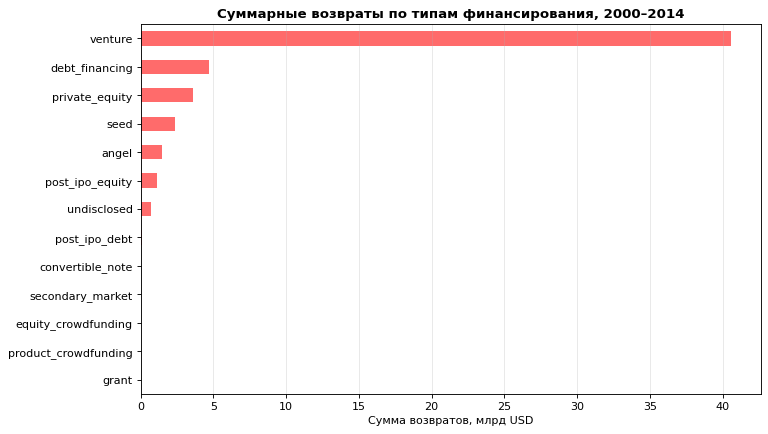

venture                 40.58
debt_financing           4.73
private_equity           3.59
seed                     2.38
angel                    1.51
post_ipo_equity          1.10
undisclosed              0.73
post_ipo_debt            0.09
convertible_note         0.03
secondary_market         0.01
equity_crowdfunding      0.00
product_crowdfunding     0.00
grant                    0.00
dtype: float64

In [25]:
# cb хранит возвраты в миллионах USD
returns_total = cb[funding_types].sum().sort_values() / 1e3   # → млрд USD

returns_total.plot(kind='barh', figsize=(10, 6), color='#FF6B6B')
plt.title('Суммарные возвраты по типам финансирования, 2000–2014', weight='bold')
plt.xlabel('Сумма возвратов, млрд USD')
plt.grid(axis='x', alpha=0.3)
plt.show()

returns_total.sort_values(ascending=False).round(2)

По абсолютному объёму возвратов с большим отрывом лидирует **venture — 40,6 млрд USD**, дальше идут debt financing (4,7 млрд), private equity (3,6 млрд) и seed (2,4 млрд). Seed — второй по популярности, но только четвёртый по возвратам. По грантам возвратов нет, что ожидаемо: это безвозвратные деньги.

Абсолютные суммы зависят от объёма вложений, поэтому ниже считаю долю возврата.

---

## 5. Динамика

### 5.1. Размер и количество раундов по годам

Для каждой компании считаю средний размер раунда (`funding_total_usd / funding_rounds`) и смотрю медиану по годам — это типичный чек одного раунда. Число раундов за год показывает активность рынка.

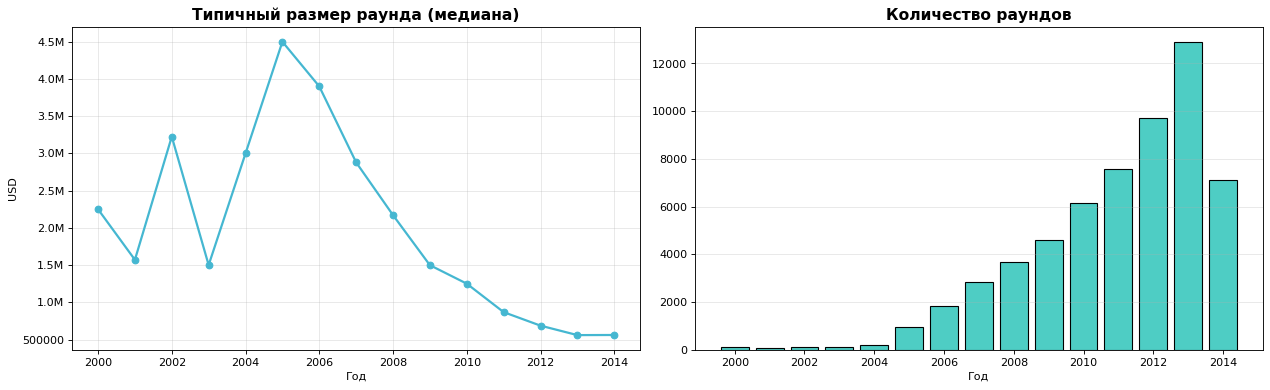

,typical_round,rounds
funding_year,,
2000,2.25 млн,113.0
2001,1.57 млн,66.0
2002,3.23 млн,98.0
2003,1.50 млн,125.0
2004,3.00 млн,181.0
2005,4.50 млн,948.0
2006,3.90 млн,1849.0
2007,2.88 млн,2842.0
2008,2.17 млн,3663.0


In [26]:
df['avg_round_size'] = df['funding_total_usd'] / df['funding_rounds']

by_year = df.groupby('funding_year').agg(
    typical_round=('avg_round_size', 'median'),
    rounds=('funding_rounds', 'sum')
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ax1.plot(by_year.index, by_year['typical_round'], marker='o', linewidth=2, color='#45B7D1')
ax1.set_title('Типичный размер раунда (медиана)', fontsize=14, weight='bold')
ax1.set_xlabel('Год')
ax1.set_ylabel('USD')
ax1.yaxis.set_major_formatter(money_axis)
ax1.grid(alpha=0.3)

ax2.bar(by_year.index, by_year['rounds'], color='#4ECDC4', edgecolor='black')
ax2.set_title('Количество раундов', fontsize=14, weight='bold')
ax2.set_xlabel('Год')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

by_year.assign(typical_round=by_year['typical_round'].map(format_money))

- **Максимальный типичный размер раунда — в 2005 году: 4,5 млн USD.** После этого чек устойчиво снижался и к 2013–2014 годам упал до ~0,56 млн.
- **Число раундов росло до 2013 года** (12 880), а в 2014 году сократилось почти вдвое (7 122). Типичный размер раунда в 2014-м при этом остался на минимальном уровне.

Рынок дробился: сделок становилось всё больше, но каждая — всё меньше. Инвесторы всё чаще «пробуют» стартап небольшой суммой и добавляют деньги в следующих раундах. Спад числа раундов в 2014 году стоит воспринимать осторожно: как видно выше, конец 2014 года представлен в данных не полностью.

### 5.2. Массовые сегменты с ростом финансирования в 2014 году

Считаю суммарное финансирование массовых сегментов по годам и отбираю те, где сумма в 2014 году выросла по сравнению с 2013-м. Заглушки `mid`, `niche` и `unknown` не учитываю — это не реальные сегменты.

In [27]:
mass = df[~df['market'].isin(['mid', 'niche', 'unknown'])]

pivot = mass.pivot_table(index='funding_year', columns='market',
                         values='funding_total_usd', aggfunc='sum', fill_value=0)

growing = pivot.columns[pivot.loc[2014] > pivot.loc[2013]]
growth = pd.DataFrame({
    '2013': pivot.loc[2013, growing],
    '2014': pivot.loc[2014, growing],
})
growth['прирост, %'] = ((growth['2014'] / growth['2013'] - 1) * 100).round(1)
growth = growth.sort_values('2014', ascending=False)
print(f'Массовых сегментов с ростом финансирования в 2014 году: {len(growing)}')
growth.assign(**{'2013': growth['2013'].map(format_money), '2014': growth['2014'].map(format_money)})

Массовых сегментов с ростом финансирования в 2014 году: 10


,2013,2014,"прирост, %"
market,,,
Manufacturing,393.94 млн,416.33 млн,5.7
Technology,120.87 млн,202.02 млн,67.1
Medical,64.47 млн,175.24 млн,171.8
Internet,69.73 млн,117.83 млн,69.0
Real Estate,92.21 млн,115.57 млн,25.3
SaaS,79.58 млн,92.81 млн,16.6
Big Data,78.70 млн,79.23 млн,0.7
Design,60.96 млн,68.99 млн,13.2
Apps,28.87 млн,66.24 млн,129.4


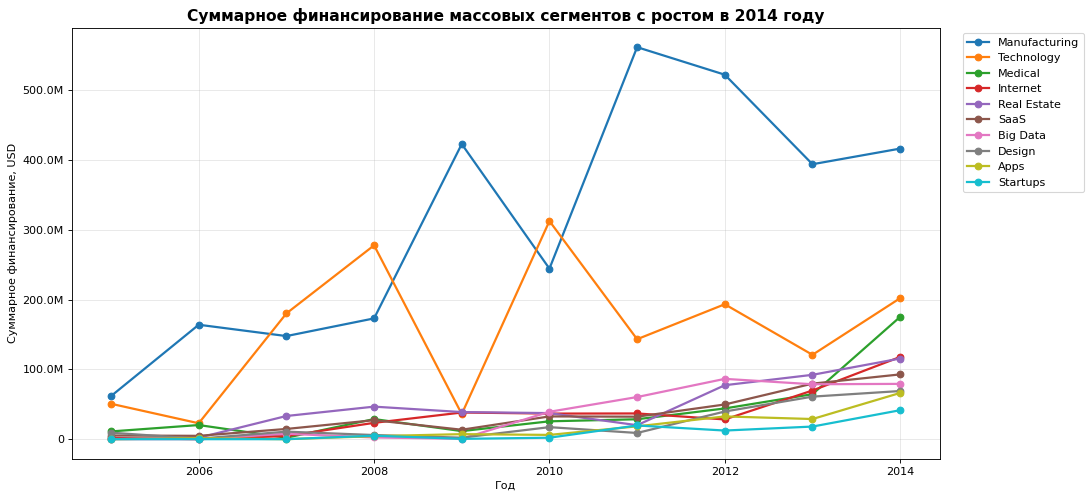

In [28]:
fig, ax = plt.subplots(figsize=(14, 7))
for segment in growth.index:
    series = pivot.loc[2005:, segment]
    ax.plot(series.index, series.values, marker='o', linewidth=2, label=segment)

ax.set_title('Суммарное финансирование массовых сегментов с ростом в 2014 году',
             fontsize=14, weight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('Суммарное финансирование, USD')
ax.yaxis.set_major_formatter(money_axis)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.show()

Рост в 2014 году показали 10 массовых сегментов.

- **Medical** — самый быстрый рост: +172% (с 64 до 175 млн USD). Сегмент рос каждый год начиная с 2011-го.
- **Internet** — +69% (с 70 до 118 млн). Рост ускорился с 2012 года.
- **Apps** и **Startups** — примерно +130%, но на небольшой базе (66 и 42 млн).
- **Technology** — +67%, но история у сегмента нестабильная: резкие провалы в 2009, 2011 и 2013 годах.
- **Manufacturing** — самый крупный по объёму (416 млн), но рост всего +6%, а по сравнению с 2011–2012 годами объём даже ниже.
- **Real Estate**, **SaaS**, **Design** растут умеренно (+13–25%), **Big Data** практически стоит на месте (+0,7%).

Сочетание устойчивого многолетнего роста и сильного ускорения в 2014 году есть у **Medical** и **Internet**.

### 5.3. Доля возвращённых средств по типам финансирования

Для каждого года и типа финансирования считаю долю возврата: возвращённые средства / вложенные средства. Значения больше 100% — артефакт данных (вложения и возвраты одного года относятся к разным компаниям), их заменяю на пропуски. Кроме средней доли смотрю разброс по годам — насколько результат устойчив.

In [29]:
invest = df.groupby('funding_year')[funding_types].sum()
returned = cb[funding_types] * 1e6            # млн → USD

years = invest.index.intersection(returned.index)
share = returned.loc[years] / invest.loc[years].replace(0, np.nan)
share = share.where(share <= 1)               # доля > 100% — артефакт данных, убираю

summary = pd.DataFrame({
    'инвестиции': invest.loc[years].sum(),
    'возвраты': returned.loc[years].sum(),
    'средняя годовая доля возврата, %': (share.mean() * 100).round(1),
    'разброс по годам (std), п.п.': (share.std() * 100).round(1),
}).sort_values('средняя годовая доля возврата, %', ascending=False)

summary.assign(инвестиции=summary['инвестиции'].map(format_money),
               возвраты=summary['возвраты'].map(format_money))

,инвестиции,возвраты,"средняя годовая доля возврата, %","разброс по годам (std), п.п."
private_equity,4.84 млрд,3.59 млрд,65.9,21.6
angel,2.48 млрд,1.51 млрд,57.1,16.3
post_ipo_equity,1.95 млрд,1.10 млрд,55.1,23.2
debt_financing,8.18 млрд,4.73 млрд,54.3,19.8
post_ipo_debt,286.72 млн,91.03 млн,53.8,35.9
seed,9.43 млрд,2.38 млрд,49.5,25.7
undisclosed,2.10 млрд,730.88 млн,48.1,22.2
venture,129.09 млрд,40.58 млрд,39.2,24.1
secondary_market,45.29 млн,5.20 млн,9.1,10.4
convertible_note,566.04 млн,34.79 млн,8.0,6.6


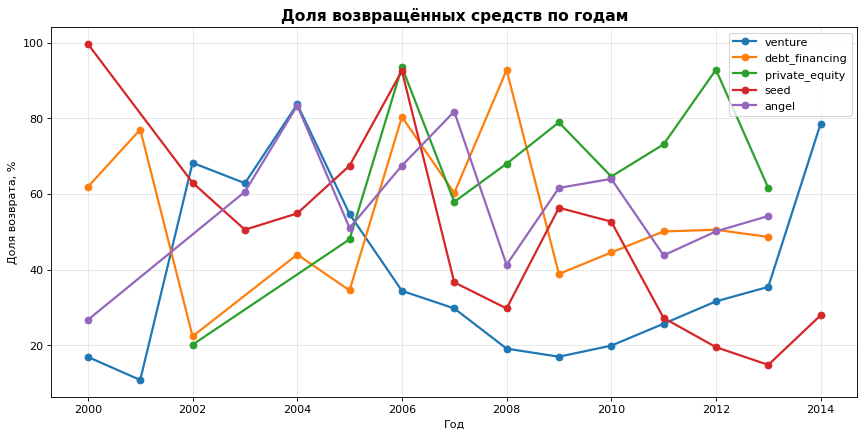

In [30]:
main_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

fig, ax = plt.subplots(figsize=(13, 6))
for t in main_types:
    s = share[t].dropna()
    ax.plot(s.index, s.values * 100, marker='o', linewidth=2, label=t)
ax.set_title('Доля возвращённых средств по годам', fontsize=14, weight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('Доля возврата, %')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

- **Лучшая доля возврата** — у `private_equity` (≈ 66% в среднем по годам), `angel` (57%), `post_ipo_equity` (55%) и `debt_financing` (54%). Это инструменты с понятным механизмом возврата: вложения в зрелые компании или долг.
- **Seed** — около 50% в среднем, но с 2011 года доля заметно ниже (15–28%).
- **Venture** — самая низкая доля среди крупных инструментов (≈ 39%). В 2008–2013 годах — стабильно 17–35%; скачок в 2014 году, скорее всего, связан с неполными данными о вложениях этого года. Ставка на венчур — это ставка на редкие, но очень крупные выходы.
- **Краудфандинг, конвертируемые займы, вторичный рынок** возвращают меньше 10%, **гранты** — 0%.
- У основных типов доля сильно колеблется по годам (стандартное отклонение 16–26 п. п.), поэтому средние доли — ориентир, а не гарантированная доходность.

---

## 6. Выводы и рекомендации

### Что показал анализ

- **Данные.** После очистки осталось 40 907 компаний, после исключения выбросов и «редких» лет — 35 588 компаний за 2000–2014 годы. Главная проблема исходных данных — пробелы в значениях `market`: из-за них число сегментов было завышено с 439 до 939.
- **Деньги идут в «долгие» компании.** 59% стартапов получили финансирование один раз, но 62% всех денег привлекли компании, которые финансировались больше года.
- **Рынок сконцентрирован.** 49 массовых сегментов (12% от всех) объединяют 89% компаний.
- **Типичное финансирование** компании — от 350 тыс. до 10 млн USD, медиана — 2 млн.
- **Venture доминирует** по объёму (≈ 80% денег), популярности и абсолютным возвратам (40,6 млрд USD), но доля возврата у него самая низкая среди крупных инструментов (≈ 39%).
- **Рынок дробится.** Типичный раунд уменьшился с 4,5 млн (2005) до ~0,56 млн (2013–2014), а число раундов росло до 2013 года.

### Рекомендация 1. Сегменты: Medical и Internet

- Самый сильный рост финансирования в 2014 году среди массовых сегментов: **Medical +172%**, **Internet +69%**.
- Рост не разовый: Medical растёт с 2011 года, Internet — с 2012-го.
- Оба сегмента массовые — большой выбор компаний для портфеля.
- Дополнительно, с большим риском, можно смотреть на **Apps** (+129%): рост быстрый, но рынок пока небольшой.
- **Manufacturing** и **Technology** как основу брать не стоит: у первого рост почти остановился, у второго нестабильная история.

### Рекомендация 2. Инструмент: venture с защитной частью в debt financing и private equity

- **Venture** — основной инструмент финансирования растущих технологических и медицинских компаний: через него проходит ≈ 80% денег рынка и больше всего возвратов в абсолютных суммах. Доля возврата у венчура самая низкая среди крупных типов, поэтому нужна диверсификация по многим компаниям.
- С учётом дробления рынка лучше заходить **поэтапно**: начинать с небольших раундов и докладывать в компании, которые проходят следующие раунды, — именно такие компании собирают основную часть денег.
- Для снижения риска часть портфеля можно направить в **debt financing** и **private equity** — у них доля возврата выше (54–66%).
- **Краудфандинг, конвертируемые займы и гранты** для цели заработать не подходят: возврат меньше 10%.

### Ограничения

- Доля возврата считается по годам на агрегированных данных: вложения и возвраты одного года относятся к разным компаниям. Это оценка эффективности инструмента, а не доходность конкретных сделок.
- Конец 2014 года представлен в данных не полностью, поэтому сравнения 2014 и 2013 годов — ориентир, который стоит перепроверить на более свежих данных.